# Future Property Price Prediction

In [223]:
import warnings
warnings.filterwarnings('ignore')

from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import mlflow
from mlflow.data import from_pandas

In [224]:
data = pd.read_csv('Datasets/Future_Price.csv')

In [225]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_per_SqFt_in_Lakhs         250000 non-null  float64
 8   Price_in_Lakhs                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Direction_Facing                250000 non-null  object 
 12  Floor_No        

### Data Preprocessing

In [226]:
# Converting categorical to numerical
binary_map = {
  'Yes':1,
  'No':0
}

cols = ['Parking_Space', 'Security']
for col in cols:
  data[col] = data[col].map(binary_map)

### Feature Variable and Target variable

In [227]:
X = data.drop(columns=['ID', 'Future_Price_5Y','State', 'Price_in_Lakhs', 'Amenity_Score'])
y = data['Future_Price_5Y']

In [228]:
X.columns

Index(['City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt',
       'Price_per_SqFt_in_Lakhs', 'Year_Built', 'Furnished_Status',
       'Direction_Facing', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Owner_Type', 'Availability_Status', 'Total_Nearby_Schools',
       'Total_Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Clubhouse', 'Garden', 'Gym', 'Playground',
       'Pool'],
      dtype='object')

### Feature Correlation with Target Variable

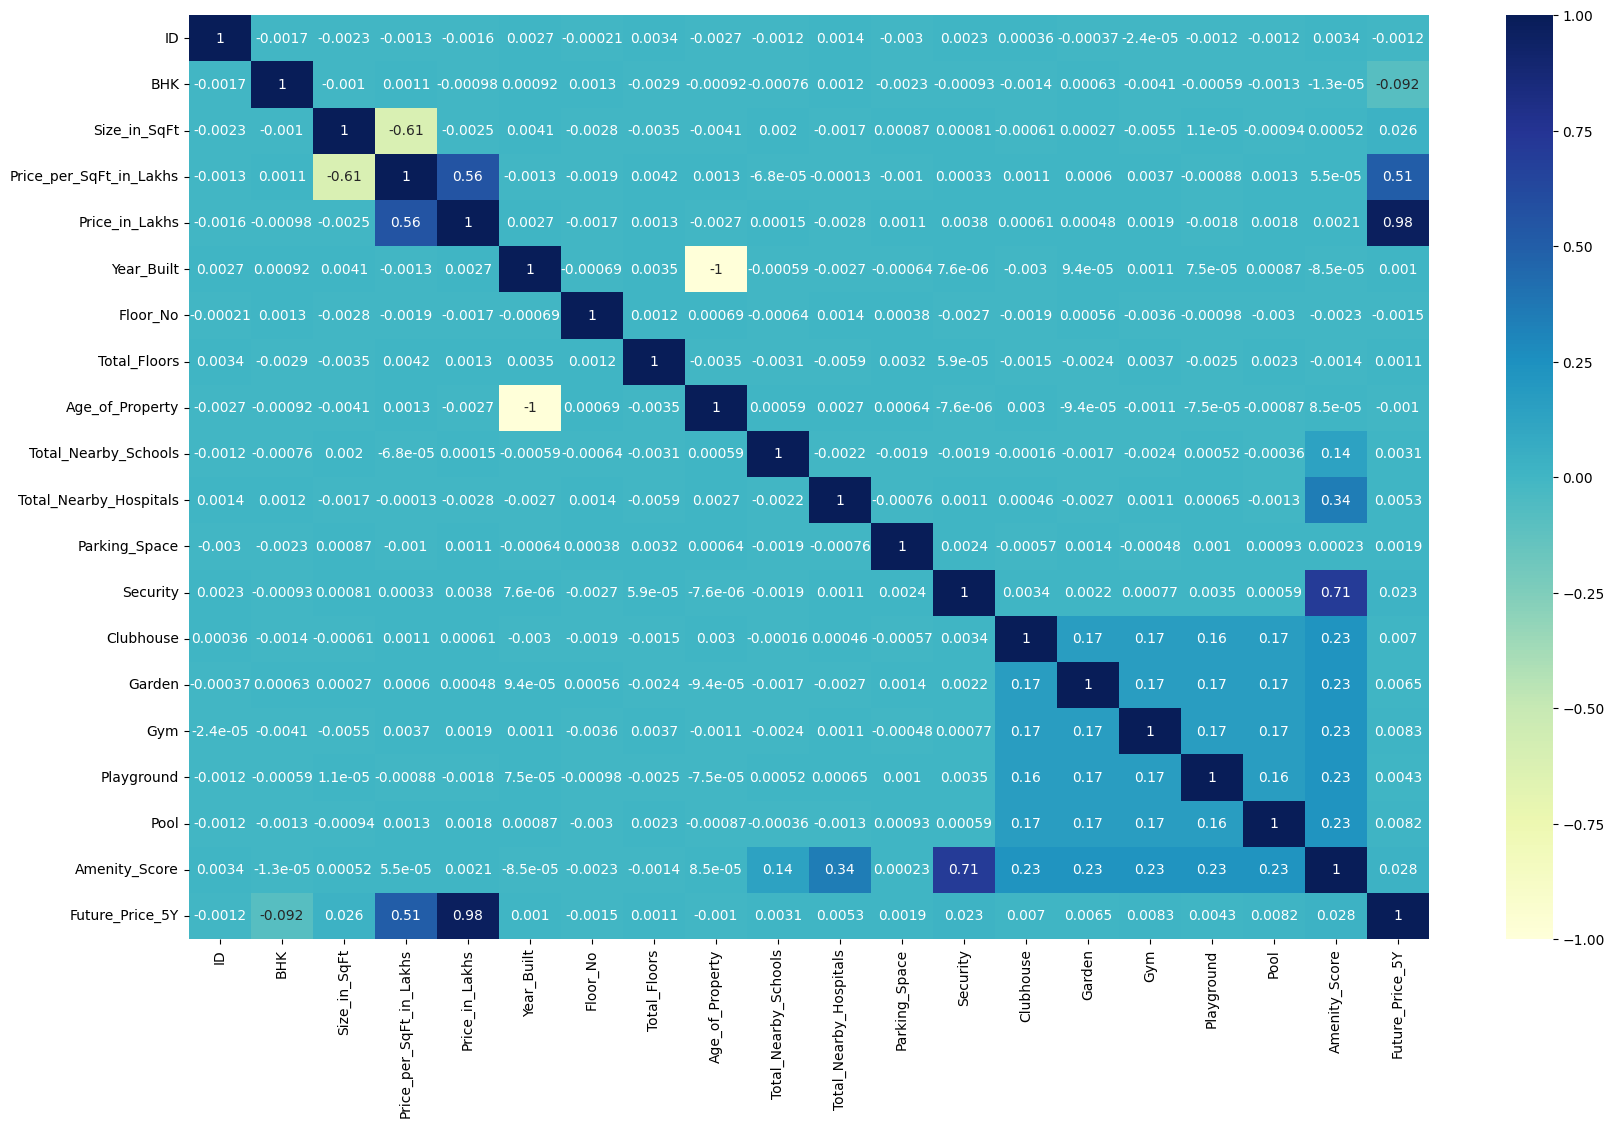

In [229]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(20,12))
sns.heatmap(
  data=corr,
  annot=True,
  cmap='YlGnBu'
)
plt.show()

### Feature selection using Mutual Information

In [230]:
X_encoded = X.copy()

for col in X_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

mi_scores = mutual_info_regression(X_encoded, y)

mi_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'MI_Score': mi_scores
})

mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

print(mi_df)

                           Feature  MI_Score
5          Price_per_SqFt_in_Lakhs  0.633214
3                              BHK  0.016449
0                             City  0.009633
4                     Size_in_SqFt  0.002640
2                    Property_Type  0.002295
18                        Security  0.001893
20                          Garden  0.001428
23                            Pool  0.001137
16  Public_Transport_Accessibility  0.000989
14            Total_Nearby_Schools  0.000550
11                 Age_of_Property  0.000485
6                       Year_Built  0.000471
1                         Locality  0.000323
10                    Total_Floors  0.000221
7                 Furnished_Status  0.000000
9                         Floor_No  0.000000
15          Total_Nearby_Hospitals  0.000000
13             Availability_Status  0.000000
12                      Owner_Type  0.000000
8                 Direction_Facing  0.000000
19                       Clubhouse  0.000000
17        

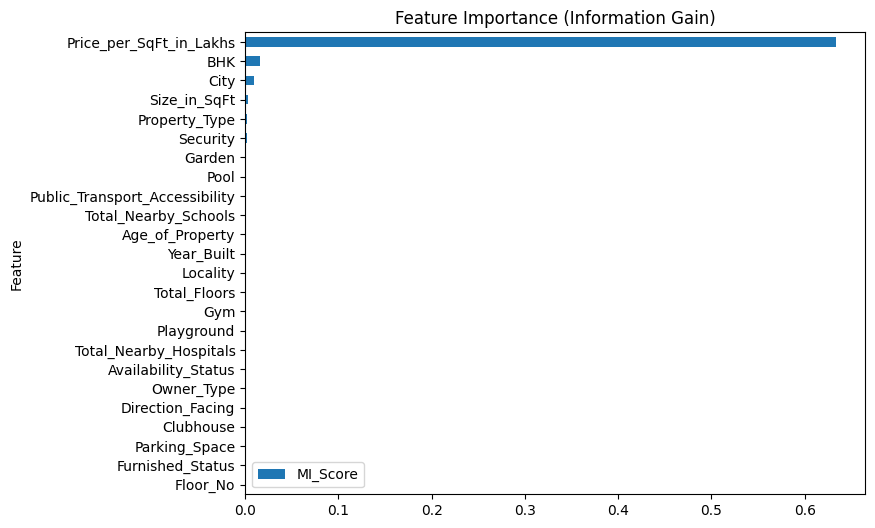

In [231]:
mi_df.sort_values(by='MI_Score').plot(
    x='Feature',
    y='MI_Score',
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance (Information Gain)")
plt.show()

### Data Preprocessing Pipeline

In [232]:
# Target Encoding City and Locality
class LocationFeatureEngineer(BaseEstimator, TransformerMixin):
  def __init__(self, city_col='City', locality_col='Locality'):
    self.city_col = city_col
    self.locality_col = locality_col

  def extract_locality_number(self, val):
    val_list = val.split("_")
    return str(val_list[1])

  def fit(self, X, y=None):
    return self

  def transform(self, X):
    X = X.copy()

    # Extract locality number
    X[self.locality_col] = X[self.locality_col].apply(self.extract_locality_number)

    # Create Location feature
    X['Location'] = X[self.city_col] + '_' + X[self.locality_col]

    # Drop original columns
    X.drop(columns=[self.city_col, self.locality_col], inplace=True)

    return X


class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):
  def __init__(self, col, smoothing=10):
    self.col = col
    self.smoothing = smoothing

  def fit(self, X, y):
    df = pd.DataFrame({
      self.col: X[self.col],
      'target': y
    })

    stats = df.groupby(self.col)['target'].agg(['mean', 'count'])

    self.global_mean_ = y.mean()

    # Smoothing formula
    self.mapping_ = (
      (stats['mean'] * stats['count'] + self.global_mean_ * self.smoothing) /
      (stats['count'] + self.smoothing)
    )

    return self

  def transform(self, X):
    X = X.copy()

    X[self.col] = X[self.col].map(self.mapping_)

    # Handle unseen values
    X[self.col] = X[self.col].fillna(self.global_mean_)

    return X

location_pipeline = Pipeline([
  ('location_feature_engineering', LocationFeatureEngineer()),
  ('target_enc', SmoothedTargetEncoder(col='Location', smoothing=10))
])

cat_pipeline = Pipeline([
  ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

std_sle_pipeline = Pipeline([
  ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
  ('ordinal', OrdinalEncoder())
])

binary_pipeline = 'passthrough'


### Model Pipeline

In [239]:
selected_features = mi_df[mi_df['MI_Score'] > 0]['Feature'].tolist()

tar_var = []
num_var = []
cat_var = []
ord_var = []
bin_var = []

for var in selected_features:

    # Drop NA for safety when checking unique values
    unique_vals = data[var].dropna().unique()

    # ✅ Step 1: Detect Binary (0/1)
    if set(unique_vals).issubset({0, 1}):
        bin_var.append(var)

    # ✅ Step 2: Numerical / Ordinal
    elif (data[var].dtype == 'float') or (data[var].dtype == 'int'):
        num_var.append(var)

    # ✅ Step 3: Categorical
    elif data[var].dtype == 'object':
        if var in ['City', 'Locality']:
            tar_var.append(var)
        elif var == 'Public_Transport_Accessibility':
            ord_var.append(var)
        else:
            cat_var.append(var)

preprocessor = ColumnTransformer([
    ('location', location_pipeline, tar_var),
    ('cat', cat_pipeline, cat_var),
    ('num', std_sle_pipeline, num_var),
    ('ordinal', ordinal_pipeline, ord_var),
    ('bin', binary_pipeline, bin_var)
])

lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

print(tar_var)
print(num_var)
print(cat_var)
print(ord_var)
print(bin_var)

['City', 'Locality']
['Price_per_SqFt_in_Lakhs', 'BHK', 'Size_in_SqFt', 'Total_Nearby_Schools', 'Age_of_Property', 'Year_Built', 'Total_Floors']
['Property_Type']
['Public_Transport_Accessibility']
['Security', 'Garden', 'Pool']


In [240]:
dataset_params = {
  'random_state':42,
  'test_size':0.2
}

X_train, X_test, y_train, y_test = train_test_split(
  X, y, random_state = dataset_params['random_state'], test_size=dataset_params['test_size']
)

In [241]:
# Fit the pipeline
lr_pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = lr_pipeline.predict(X_train)
y_test_pred = lr_pipeline.predict(X_test)

In [242]:
model_params = lr_pipeline.named_steps['model'].get_params()
model_params = {k: str(v) for k, v in model_params.items()}

model_metrics = {
    "train_r2": r2_score(y_train, y_train_pred),
    "test_r2": r2_score(y_test, y_test_pred),

    "train_mae": mean_absolute_error(y_train, y_train_pred),
    "test_mae": mean_absolute_error(y_test, y_test_pred),

    "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
    "test_rmse": np.sqrt(mean_squared_error(y_test, y_test_pred)),
}

In [243]:
# MLFlow tracking
load_dotenv()

tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
experiment_name = os.getenv("MLFLOW_EXPERIMENT_NAME_REG")

mlflow.set_experiment(experiment_name)
mlflow.set_tracking_uri(tracking_uri)

with mlflow.start_run(run_name="Linear Regression"):
  
  dataset = from_pandas(X_train, name="X_train_dataset")
  mlflow.log_input(dataset, context='training_data')
  print("Input Logged")

  mlflow.log_params(model_params)
  mlflow.log_params({"MI_Score" : "> 0"})
  print("Parameters Logged")

  mlflow.log_metrics(model_metrics)
  print("Metrics Logged")

  mlflow.sklearn.log_model(lr_pipeline, "Linear Regression")
  print("Model Logged")


Input Logged
Parameters Logged


2026/04/07 18:03:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Metrics Logged


2026/04/07 18:03:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model Logged
🏃 View run Linear Regression at: http://localhost:5000/#/experiments/1/runs/369a12d087e1421fa3c0f9d396b2d3b7
🧪 View experiment at: http://localhost:5000/#/experiments/1
